# Đánh giá & So sánh 2 Mô hình AI (Báo cáo Đồ án)
Notebook này kế thừa 100% cấu hình từ thư mục `src/`, tự động cắt đúng tập Test (cố định theo seed) để tránh rò rỉ dữ liệu.

# Kết nối với Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
# 1. Chui vào đúng thư mục dự án (nơi chứa thư mục src/)
os.chdir('/content/drive/MyDrive/VietFood-Project/vnfood_vision')
print("Thư mục hiện tại:", os.getcwd())

# 2. Khai báo nơi chứa ảnh (Y hệt file Train của bạn)
os.environ['VNFOOD_DATA_DIR'] = "/content/drive/MyDrive/VietFood-Project/data/processed"


Mounted at /content/drive
Thư mục hiện tại: /content/drive/MyDrive/vnfood_vision


# Xác định môi trường chạy

In [2]:
import sys
from pathlib import Path
import os

# Trỏ về thư mục gốc của dự án để gọi src
# (Vì Notebook này nằm trong thư mục notebooks/)
project_root = Path(os.getcwd())

sys.path.append(str(project_root))

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split

# Import module từ source
from src.dataset import VietnameseFoodDataset, get_transforms
from src.model import VNFoodModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Đang sử dụng thiết bị:', device)

Đang sử dụng thiết bị: cuda


# Copy thư mục code và Data vào content để chạy

In [4]:
# Ô 1: KẾT NỐI DRIVE VÀ COPY DATA VÀO COLAB (CHẠY 10-15 PHÚT)
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/VietFood-Project/vnfood_vision"
DATA_DIR = "/content/drive/MyDrive/VietFood-Project/data/processed"

# 1. Copy toàn bộ Code
LOCAL_PROJECT = "/content/vnfood_vision"
if os.path.exists(LOCAL_PROJECT):
    shutil.rmtree(LOCAL_PROJECT)
shutil.copytree(PROJECT_DIR, LOCAL_PROJECT)
os.chdir(LOCAL_PROJECT)
print(f"✅ Code đã copy vào: {LOCAL_PROJECT}")

# 2. Copy toàn bộ Ảnh (Data)
LOCAL_DATA = "/content/data/processed"
if not os.path.exists(LOCAL_DATA):
    print("Đang copy ảnh từ Drive về local... (chờ 10-15 phút)")
    shutil.copytree(DATA_DIR, LOCAL_DATA)
print("✅ Data đã sẵn sàng tại:", LOCAL_DATA)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Code đã copy vào: /content/vnfood_vision
Đang copy ảnh từ Drive về local... (chờ 10-15 phút)
✅ Data đã sẵn sàng tại: /content/data/processed


# Chia lại train/test/val

In [5]:
# 1. Đọc config.yaml và khởi tạo Dataset
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Tự động lấy biến DATA_DIR trên Colab
data_dir = '/content/data/processed'
print('Thư mục Data:', data_dir)

# 2. Khởi tạo Dataset đầy đủ (Chỉ dùng transform của Val/Test)
val_transform = get_transforms(config, mode='val')
full_dataset = VietnameseFoodDataset(root_dir=data_dir, transform=val_transform)
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

# 3. Tính toán độ dài y hệt như trong train.py
n_val  = int(len(full_dataset) * config['data']['val_split'])
n_test = int(len(full_dataset) * config['data']['test_split'])
n_train = len(full_dataset) - n_val - n_test

# CẮT TẬP TEST CỐ ĐỊNH THEO SEED (Khắc phục hoàn toàn Data Leakage)
_, _, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(config['data']['seed'])
)

test_loader = DataLoader(
    test_ds, batch_size=config['data']['batch_size'], shuffle=False, num_workers=config['data']['num_workers']
)
print(f'\n✅ Tập Test cố định: {len(test_ds)} ảnh / {num_classes} món.')

Thư mục Data: /content/data/processed

✅ Tập Test cố định: 3935 ảnh / 43 món.


# Load lại mô hình để đánh giá

In [8]:
import torch
import sys
import os

# Đảm bảo Colab hiểu được đường dẫn tới thư mục gốc chứa code
if '/content/vnfood_vision' not in sys.path:
    sys.path.append('/content/vnfood_vision')

# Import kiến trúc mạng mà chúng ta đã xây dựng trong file src/model.py
from src.model import VNFoodModel

def load_trained_model(backbone_name, ckpt_path):
    # 1. Xác định môi trường chạy (Dùng GPU nếu có, không thì CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"❌ KHÔNG TÌM THẤY FILE TRỌNG SỐ TẠI:\n{ckpt_path}\n(Bạn hãy check lại xem file best_model.pth đã được copy về đúng chỗ chưa)")

    # 2. Đọc tệp tin checkpoint
    checkpoint = torch.load(ckpt_path, map_location=device)
    num_classes = checkpoint.get('num_classes', 43)

    # 3. Khởi tạo "Bộ khung xương" (Model Architecture)
    # Lưu ý: pretrained=False vì ta không cần tải tạ từ ImageNet nữa, ta sẽ dùng tạ của chính mình
    model = VNFoodModel(
        backbone_name=backbone_name,
        num_classes=num_classes,
        pretrained=False
    )

    # 4. Bơm "Cơ bắp" (Trọng số - Weights) từ file checkpoint vào Bộ khung xương
    model.load_state_dict(checkpoint['state_dict'])

    # 5. Chuyển mô hình sang chế độ Làm Bài Thi (Khóa các lớp Dropout và BatchNorm lại)
    model.eval()

    # Ném mô hình lên GPU để dự đoán với tốc độ ánh sáng
    model.to(device)

    val_acc = checkpoint.get('val_acc1', 0)
    print(f"✅ Tải thành công {backbone_name} (Best Val Accuracy từng đạt: {val_acc:.2f}%)")

    return model


In [9]:
# ==========================================
# ĐỌC TRỌNG SỐ TỪ TRONG LOCAL COLAB (TỐC ĐỘ CAO)
# ==========================================
ckpt1_path = '/content/vnfood_vision/checkpoints/mobilenet_v3_large/best_model.pth'
ckpt2_path = '/content/vnfood_vision/checkpoints/efficientnet_b3/best_model.pth'

print('Đang khởi tạo Model 1...')
# Chú ý: Truyền đúng cái tên mạng là 'mobilenet_v3_large'
model1 = load_trained_model('mobilenet_v3_large', ckpt1_path)

print('Đang khởi tạo Model 2...')
model2 = load_trained_model('efficientnet_b3', ckpt2_path)


Đang khởi tạo Model 1...
✅ Tải thành công mobilenet_v3_large (Best Val Accuracy từng đạt: 76.57%)
Đang khởi tạo Model 2...
✅ Tải thành công efficientnet_b3 (Best Val Accuracy từng đạt: 82.34%)


# Tiến hành đánh giá

In [10]:
# 5. Chạy đánh giá
def evaluate(model, dataloader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

print('Đang quét tập test cho Model 1...')
y_true_1, y_pred_1 = evaluate(model1, test_loader)
print('Đang quét tập test cho Model 2...')
y_true_2, y_pred_2 = evaluate(model2, test_loader)
print('✅ Đánh giá hoàn tất!')

Đang quét tập test cho Model 1...
Đang quét tập test cho Model 2...
✅ Đánh giá hoàn tất!


# Vẽ ma trận nhầm lẫn


 BÁO CÁO MODEL 1
                  precision    recall  f1-score   support

        banh_bao       1.00      1.00      1.00        18
        banh_beo       0.89      0.95      0.92        86
    banh_bot_loc       0.90      0.87      0.89        94
        banh_can       0.94      0.95      0.94        96
       banh_canh       0.83      0.76      0.79       122
      banh_chung       0.91      0.94      0.92        78
       banh_cuon       0.92      0.93      0.92       163
        banh_duc       0.93      0.88      0.91        78
        banh_gio       0.97      0.91      0.94        96
       banh_khot       0.95      0.97      0.96       105
         banh_mi       0.98      0.99      0.98       201
        banh_pia       0.97      0.98      0.98        63
        banh_tet       0.98      0.94      0.96       112
banh_trang_nuong       0.93      0.92      0.92       126
 banh_trang_tron       0.00      0.00      0.00         0
        banh_xeo       0.97      0.96      0.96      

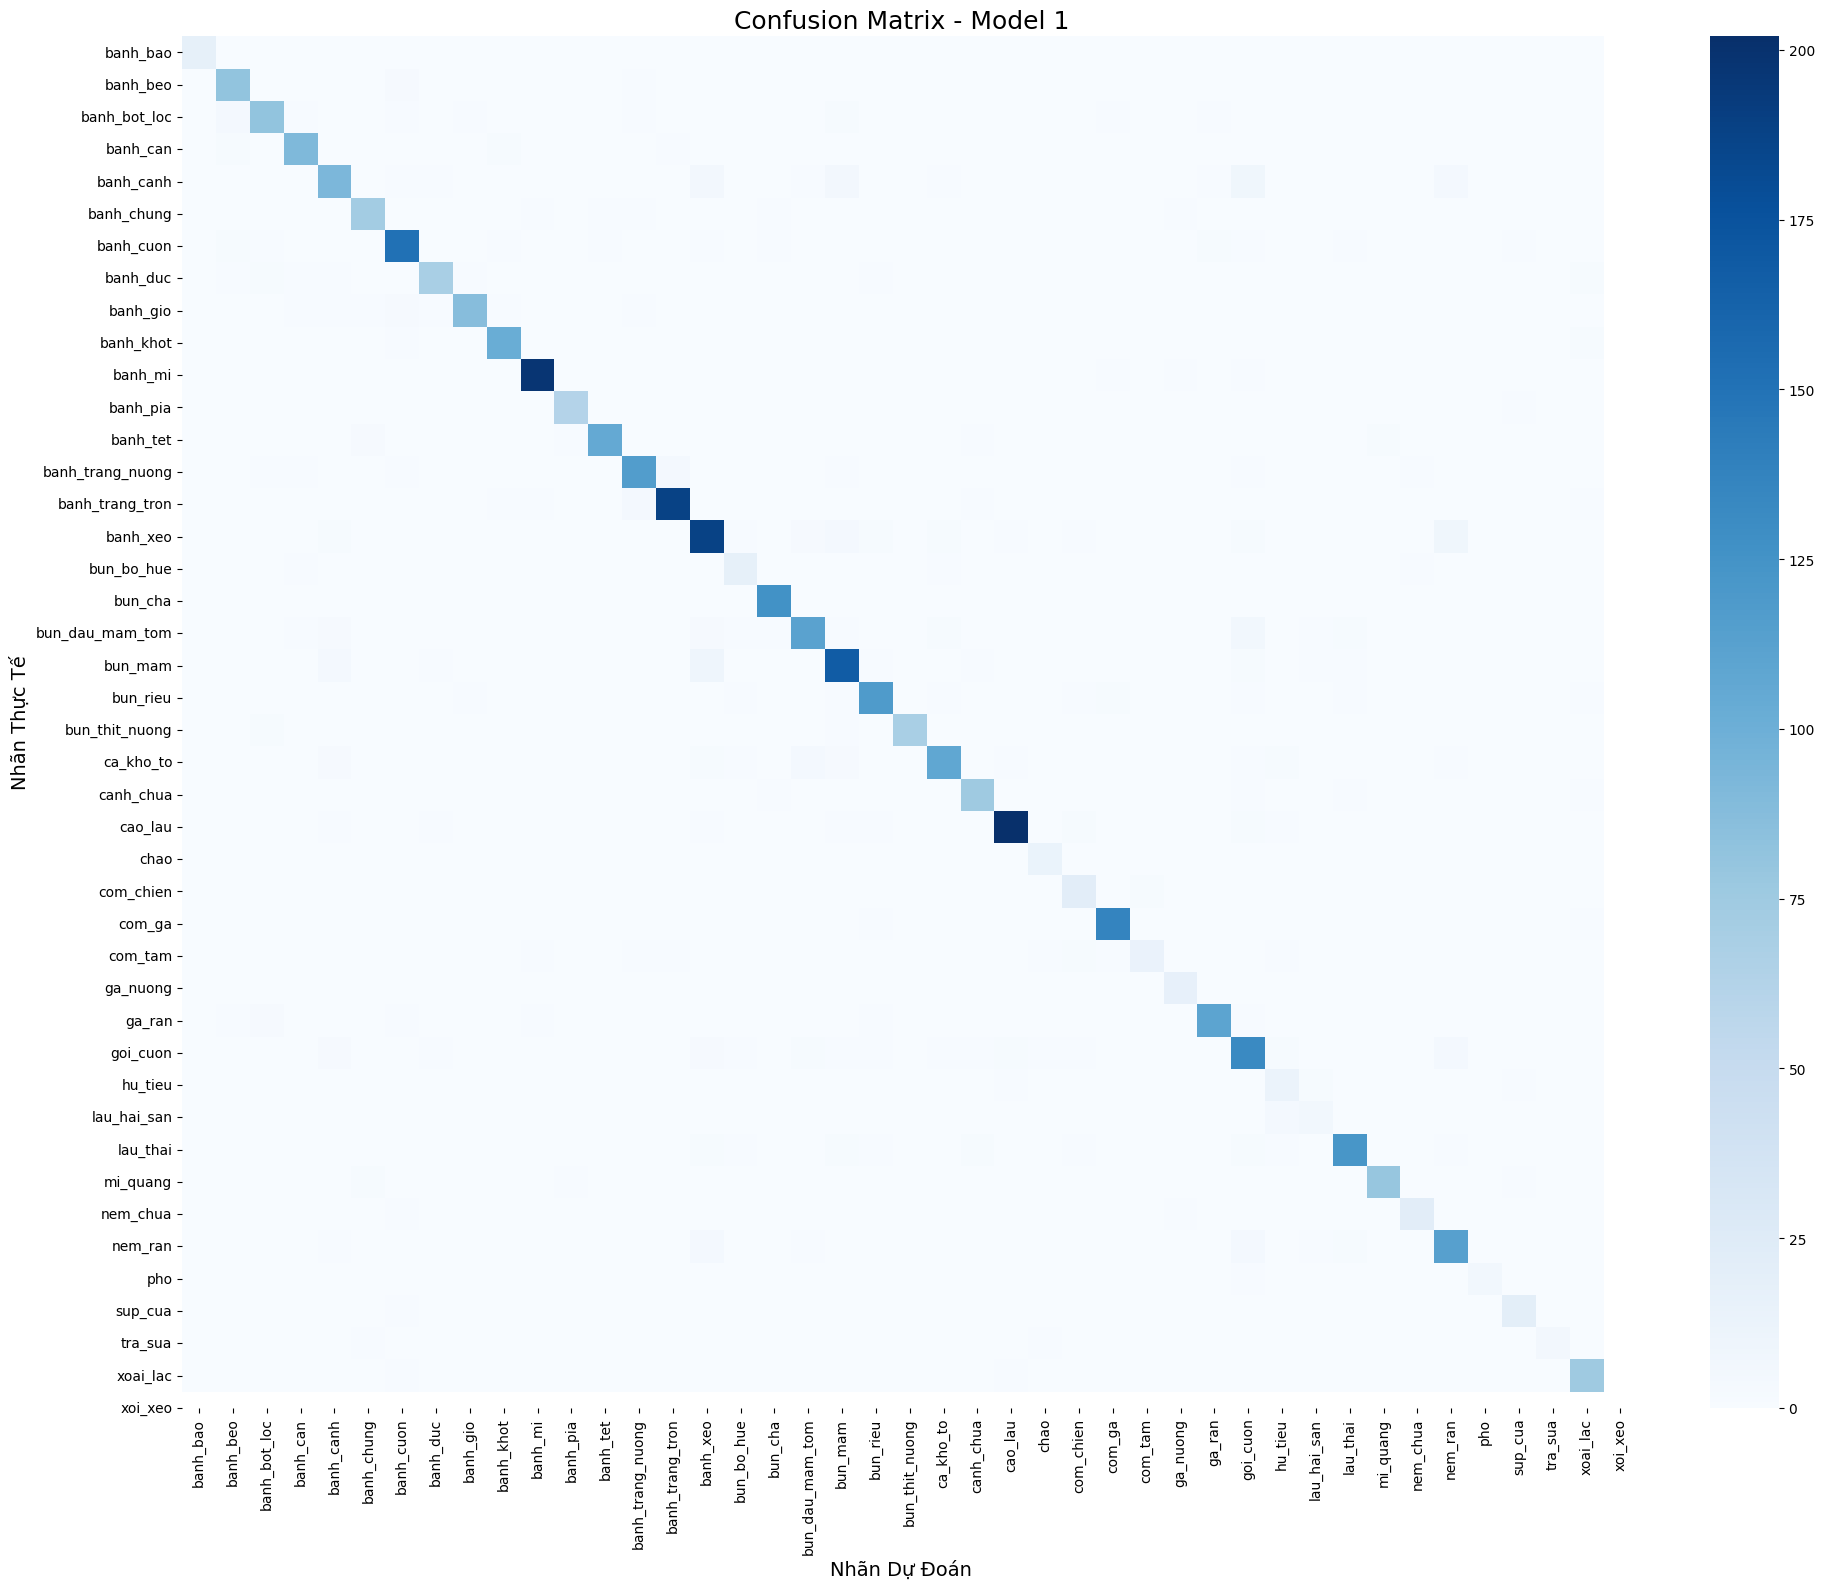

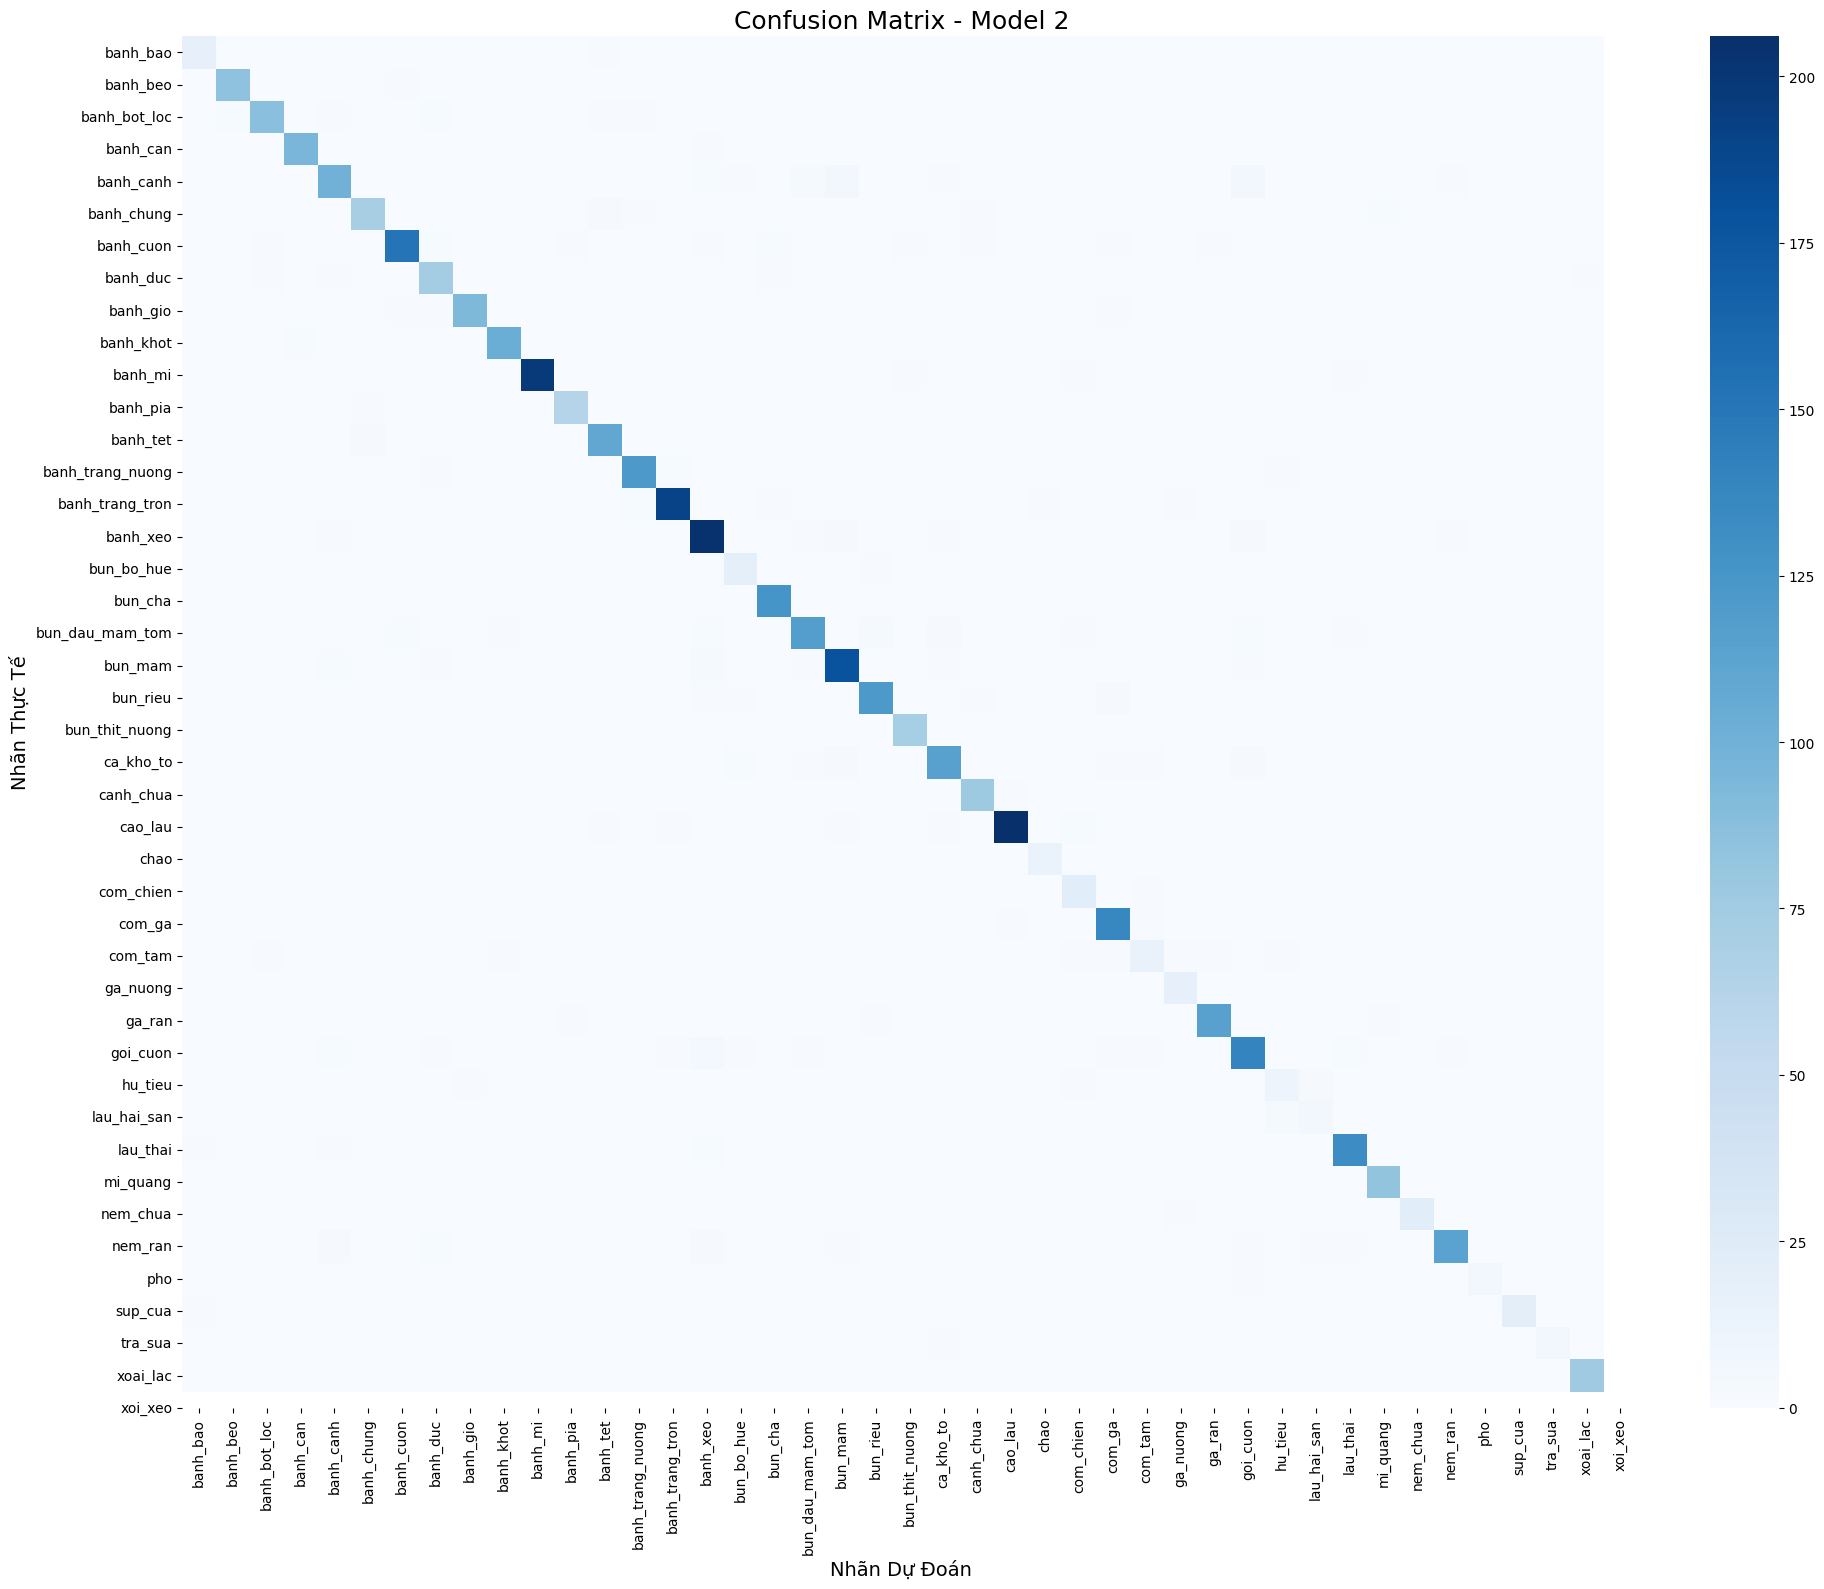

In [11]:
# 6. Xuất báo cáo và Confusion Matrix
print("\n" + "="*50)
print(" BÁO CÁO MODEL 1")
print("="*50)
# print(classification_report(y_true_1, y_pred_1, target_names=class_names))
print(classification_report(y_true_1, y_pred_1, labels=range(len(class_names)), target_names=class_names, zero_division=0))


print("\n" + "="*50)
print(" BÁO CÁO MODEL 2")
print("="*50)
# print(classification_report(y_true_2, y_pred_2, target_names=class_names))

print(classification_report(y_true_2, y_pred_2, labels=range(len(class_names)), target_names=class_names, zero_division=0))
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, cmap='Blues', annot=False, xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=18)
    plt.ylabel('Nhãn Thực Tế', fontsize=14)
    plt.xlabel('Nhãn Dự Đoán', fontsize=14)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_cm(y_true_1, y_pred_1, 'Confusion Matrix - Model 1')
plot_cm(y_true_2, y_pred_2, 'Confusion Matrix - Model 2')

In [12]:
# ==========================================
# 7. XUẤT BÁO CÁO DẠNG JSON & PHÂN TÍCH CHUYÊN SÂU
# ==========================================
import json
import os
import pandas as pd
from IPython.display import display

# 1. Tạo thư mục lưu trữ nếu chưa có
output_dir = '/content/vnfood_vision/outputs/val'
os.makedirs(output_dir, exist_ok=True)

# 2. Tạo báo cáo dạng Dictionary (Từ vựng)
report1_dict = classification_report(y_true_1, y_pred_1, labels=range(len(class_names)), target_names=class_names, output_dict=True, zero_division=0)

report2_dict = classification_report(y_true_2, y_pred_2, labels=range(len(class_names)), target_names=class_names, output_dict=True, zero_division=0)


# 3. Lưu ra file JSON
report1_path = os.path.join(output_dir, 'mobilenet_v3_large_report.json')
with open(report1_path, 'w', encoding='utf-8') as f:
    json.dump(report1_dict, f, ensure_ascii=False, indent=4)

report2_path = os.path.join(output_dir, 'efficientnet_b3_report.json')
with open(report2_path, 'w', encoding='utf-8') as f:
    json.dump(report2_dict, f, ensure_ascii=False, indent=4)

print(f"✅ Đã lưu báo cáo Model 1 tại: {report1_path}")
print(f"✅ Đã lưu báo cáo Model 2 tại: {report2_path}")
print("-" * 60)

# ==========================================
# BONUS TỰ ĐỘNG PHÂN TÍCH: TÌM ĐIỂM YẾU CỦA MÔ HÌNH
# ==========================================
def analyze_worst_classes(report_dict, model_name):
    # Chuyển JSON thành bảng Pandas
    df = pd.DataFrame(report_dict).transpose()
    # Bỏ các dòng thống kê tổng
    df_classes = df.drop(['accuracy', 'macro avg', 'weighted avg'])
    # Lọc ra 5 món có điểm F1 thấp nhất
    worst_classes = df_classes.sort_values(by='f1-score').head(5)

    print(f"\n🔻 TÌNH BÁO ĐIỂM YẾU: TOP 5 MÓN ĂN {model_name} HAY NHẬN DIỆN SAI NHẤT")
    print("(Gợi ý báo cáo: Đề xuất thu thập thêm ảnh sạch cho các món này)")
    display(worst_classes[['precision', 'recall', 'f1-score', 'support']])

analyze_worst_classes(report1_dict, "MobileNet")
analyze_worst_classes(report2_dict, "EfficientNet")


✅ Đã lưu báo cáo Model 1 tại: /content/vnfood_vision/outputs/val/mobilenet_v3_large_report.json
✅ Đã lưu báo cáo Model 2 tại: /content/vnfood_vision/outputs/val/efficientnet_b3_report.json
------------------------------------------------------------

🔻 TÌNH BÁO ĐIỂM YẾU: TOP 5 MÓN ĂN MobileNet HAY NHẬN DIỆN SAI NHẤT
(Gợi ý báo cáo: Đề xuất thu thập thêm ảnh sạch cho các món này)


,precision,recall,f1-score,support
banh_trang_tron,0.000000,0.000000,0.000000,0.0
lau_thai,0.583333,0.636364,0.608696,11.0
lau_hai_san,0.521739,0.750000,0.615385,16.0
ga_nuong,0.875000,0.636364,0.736842,22.0
banh_canh,0.830357,0.762295,0.794872,122.0



🔻 TÌNH BÁO ĐIỂM YẾU: TOP 5 MÓN ĂN EfficientNet HAY NHẬN DIỆN SAI NHẤT
(Gợi ý báo cáo: Đề xuất thu thập thêm ảnh sạch cho các món này)


,precision,recall,f1-score,support
banh_trang_tron,0.000000,0.000000,0.000000,0.0
lau_thai,0.636364,0.636364,0.636364,11.0
lau_hai_san,0.647059,0.687500,0.666667,16.0
ga_nuong,0.789474,0.681818,0.731707,22.0
banh_canh,0.900901,0.819672,0.858369,122.0


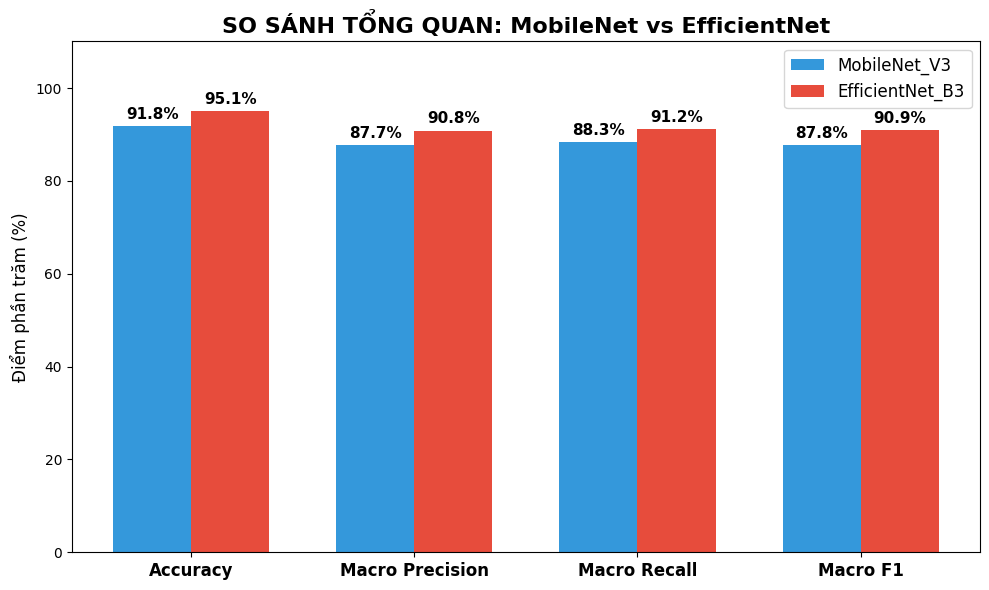

/tmp/ipykernel_1822/1131594983.py:71: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


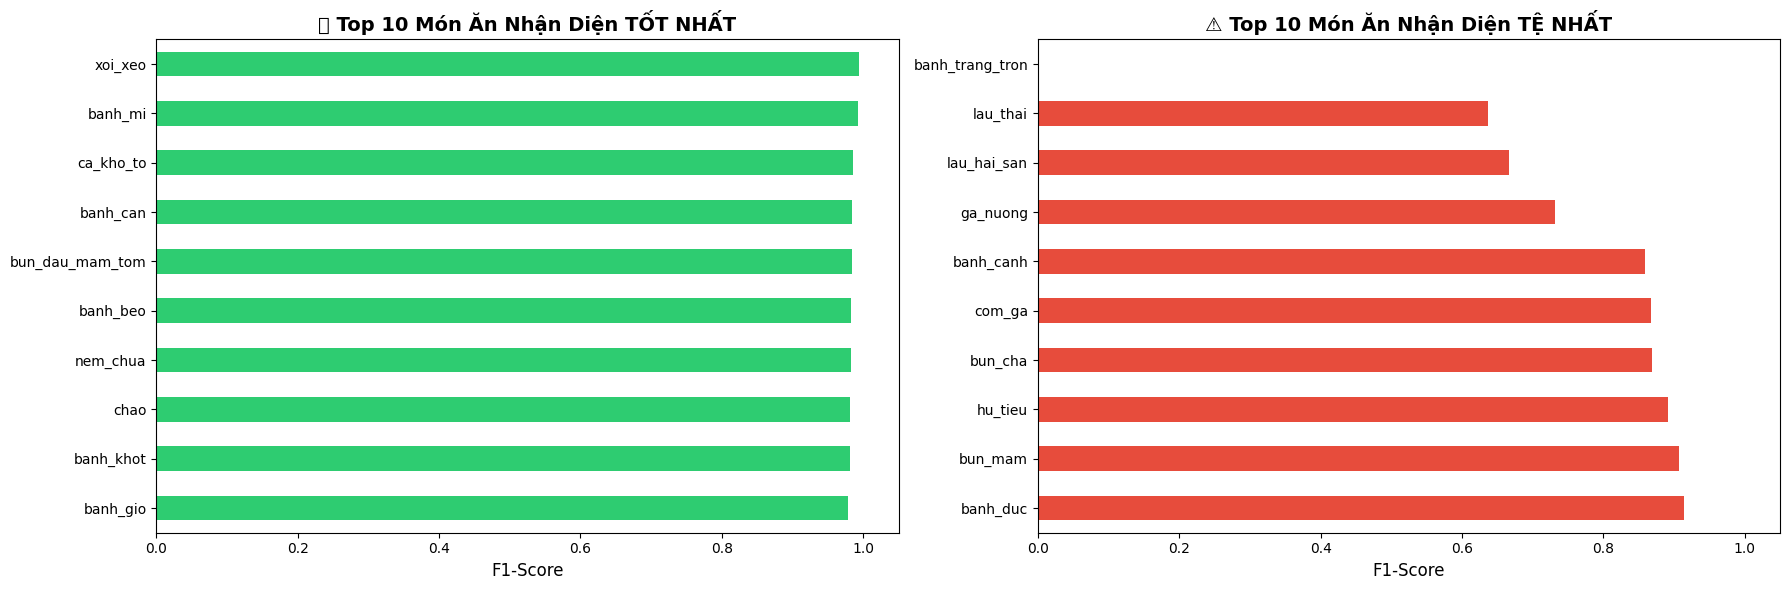

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. BIỂU ĐỒ SO SÁNH HIỆU SUẤT 2 MÔ HÌNH
# ==========================================
metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
m1_scores = [
    report1_dict['accuracy'],
    report1_dict['macro avg']['precision'],
    report1_dict['macro avg']['recall'],
    report1_dict['macro avg']['f1-score']
]
m2_scores = [
    report2_dict['accuracy'],
    report2_dict['macro avg']['precision'],
    report2_dict['macro avg']['recall'],
    report2_dict['macro avg']['f1-score']
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, [s*100 for s in m1_scores], width, label='MobileNet_V3', color='#3498db')
rects2 = ax.bar(x + width/2, [s*100 for s in m2_scores], width, label='EfficientNet_B3', color='#e74c3c')

ax.set_ylabel('Điểm phần trăm (%)', fontsize=12)
ax.set_title('SO SÁNH TỔNG QUAN: MobileNet vs EfficientNet', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, max(max(m1_scores), max(m2_scores))*100 + 15) # Tự động căn lề trên

# Viết số phần trăm lên đỉnh cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=11, fontweight='bold')
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# ==========================================
# 2. BIỂU ĐỒ TOP 10 MÓN TỐT NHẤT VÀ TỆ NHẤT (Dựa trên Model 2 - EfficientNet)
# ==========================================
df = pd.DataFrame(report2_dict).transpose()
df_classes = df.drop(['accuracy', 'macro avg', 'weighted avg'])

top_10_best = df_classes.sort_values(by='f1-score', ascending=False).head(10)
top_10_worst = df_classes.sort_values(by='f1-score', ascending=True).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Vẽ Top 10 Best
top_10_best['f1-score'].sort_values().plot(kind='barh', ax=ax1, color='#2ecc71')
ax1.set_title('🌟 Top 10 Món Ăn Nhận Diện TỐT NHẤT', fontsize=14, fontweight='bold')
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_xlim(0, 1.05)

# Vẽ Top 10 Worst
top_10_worst['f1-score'].sort_values(ascending=False).plot(kind='barh', ax=ax2, color='#e74c3c')
ax2.set_title('⚠️ Top 10 Món Ăn Nhận Diện TỆ NHẤT', fontsize=14, fontweight='bold')
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()
